# Modelo de Clasificación - Detección de Anomalías en Consumo Eléctrico
<br>

**Objetivo:** Desarrollar un modelo de clasificación para detectar anomalías en el consumo eléctrico utilizando **SVM, XGBoost, KNN y Random Forest** con optimización de hiperparámetros.

**Variable Objetivo:** `Abnormal_Usage` (0 = Normal, 1 = Anómalo)

**Algoritmos a utilizar:**
- Support Vector Machine (SVM)
- XGBoost (Extreme Gradient Boosting)
- K-Nearest Neighbors (KNN)
- Random Forest

## 1. Importar las librerías necesarias

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score, 
                             roc_curve, precision_recall_curve, average_precision_score)

# Modelos
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Para manejo de desbalance (si es necesario)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import pickle

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar los datos limpios

In [2]:
# Cargar el dataset limpio
df = pd.read_csv('dataset_limpio.csv')

print("Datos cargados:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_limpio.csv'

## 3. Verificación de los datos preprocesados

In [ ]:
# Información del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Num_Occupants                    10800 non-null  int64  
 1   House_Area (sqft)                10800 non-null  float64
 2   Appliance_Score                  10800 non-null  int64  
 3   Connected_Load(kw)               10800 non-null  float64
 4   Temperature_C                    10800 non-null  float64
 5   Humidity (%)                     10800 non-null  float64
 6   Expected_Energy(kwh)             10800 non-null  float64
 7   Actual_Energy(kwh)               10800 non-null  float64
 8   Usage_Deviation(%)               10800 non-null  float64
 9   Cluster_Avg_Energy(kwh)          10800 non-null  float64
 10  Abnormal_Usage                   10800 non-null  int64  
 11  Month                            10800 non-null  int64 

In [ ]:
# Verificar valores faltantes
print("Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

Valores faltantes:
No hay valores faltantes


In [ ]:
# Distribución de la variable objetivo
print("Distribución de la variable objetivo (Abnormal_Usage):")
print(df['Abnormal_Usage'].value_counts())
print(f"\nPorcentajes:")
print(df['Abnormal_Usage'].value_counts(normalize=True) * 100)

Distribución de la variable objetivo (Abnormal_Usage):
Abnormal_Usage
0    6061
1    4739
Name: count, dtype: int64

Porcentajes:
Abnormal_Usage
0    56.12037
1    43.87963
Name: proportion, dtype: float64


## 4. Preparación de los datos para modelado

### 4.1 Separar features (X) y variable objetivo (y)

In [ ]:
# Separar features y target
X = df.drop('Abnormal_Usage', axis=1)
y = df['Abnormal_Usage']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nFeatures utilizadas: {X.columns.tolist()}")

Shape de X (features): (10800, 18)
Shape de y (target): (10800,)

Features utilizadas: ['Num_Occupants', 'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)', 'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)', 'Month', 'Year', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_TVM', 'Dwelling_Type_Apartment', 'Dwelling_Type_Independent House', 'Dwelling_Type_Villa']


### 4.2 División en conjuntos de entrenamiento y prueba

In [ ]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Mantener la proporción de clases
)

print("División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f"  - Prueba: {X_test.shape[0]} muestras ({(len(X_test)/len(X))*100:.1f}%)")

print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts())

División de datos:
  - Entrenamiento: 8640 muestras (80.0%)
  - Prueba: 2160 muestras (20.0%)

Distribución de clases en entrenamiento:
Abnormal_Usage
0    4849
1    3791
Name: count, dtype: int64

Distribución de clases en prueba:
Abnormal_Usage
0    1212
1     948
Name: count, dtype: int64


### 4.3 Escalado de features

In [ ]:
# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con train y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index) 
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index) 

print("Datos escalados correctamente")
print(f"\nEstadísticas después del escalado (train):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Datos escalados correctamente

Estadísticas después del escalado (train):
      Num_Occupants  House_Area (sqft)  Appliance_Score  Connected_Load(kw)  \
mean            0.0                0.0              0.0                -0.0   
std             1.0                1.0              1.0                 1.0   

      Temperature_C  Humidity (%)  Expected_Energy(kwh)  Actual_Energy(kwh)  \
mean            0.0          -0.0                  -0.0                 0.0   
std             1.0           1.0                   1.0                 1.0   

      Usage_Deviation(%)  Cluster_Avg_Energy(kwh)  Month  Year  \
mean                -0.0                     -0.0    0.0   0.0   
std                  1.0                      1.0    0.0   0.0   

      Region_Code_IN_KL_ALP  Region_Code_IN_KL_ERN  Region_Code_IN_KL_TVM  \
mean                   -0.0                   -0.0                   -0.0   
std                     1.0                    1.0                    1.0   

      Dwelling_Type

## 5. Modelo 1: Support Vector Machine (SVM)

### 5.1 Modelo base (sin optimización)

In [ ]:
# Entrenar SVM con parámetros por defecto
print("Entrenando SVM con parámetros por defecto...")
svm_base = SVC(random_state=RANDOM_STATE, probability=True)
svm_base.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm_base = svm_base.predict(X_test_scaled)
y_pred_proba_svm_base = svm_base.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("RESULTADOS SVM BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_base):.4f}") 
print(f"Precision: {precision_score(y_test, y_pred_svm_base):.4f}") #Precision es la capacidad del modelo para no etiquetar como positivo (anómalo) un caso que es negativo (normal).
print(f"Recall: {recall_score(y_test, y_pred_svm_base):.4f}") #recall es la capacidad del modelo para identificar correctamente los casos positivos (anómalos)
print(f"F1-Score: {f1_score(y_test, y_pred_svm_base):.4f}") #F1-Score es la media armónica entre precision y recall, útil para evaluar modelos en datasets desbalanceados.
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_base):.4f}") #ROC-AUC sirve para evaluar la capacidad del modelo para distinguir entre clases.

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_base, target_names=['Normal', 'Anómalo']))

Entrenando SVM con parámetros por defecto...
RESULTADOS SVM BASE
Accuracy: 0.8931
Precision: 0.9786
Recall: 0.7732
F1-Score: 0.8639
ROC-AUC: 0.9420

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91      1212
     Anómalo       0.98      0.77      0.86       948

    accuracy                           0.89      2160
   macro avg       0.91      0.88      0.89      2160
weighted avg       0.91      0.89      0.89      2160



### 5.2 Optimización con Grid Search

Hiperparámetros a optimizar:
- C: Parámetro de regularización
- kernel: Tipo de kernel
- gamma: Coeficiente del kernel

Se usa una muestra estratificada del 30 % para la búsqueda. El modelo final se entrena con todos los datos.

In [ ]:
# Tomar 30% de los datos para búsqueda
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, 
    train_size=0.3,  
    random_state=RANDOM_STATE, # Para reproducibilidad
    stratify=y_train    # Mantiene la proporción de clases
)

print(f"Tamaño del dataset de entrenamiento completo: {len(X_train_scaled):,}")
print(f"Tamaño de la muestra para Grid Search: {len(X_train_sample):,}")

Tamaño del dataset de entrenamiento completo: 8,640
Tamaño de la muestra para Grid Search: 2,592


In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],                  # 3 valores
    'kernel': ['rbf'],                  # Solo RBF (el más usado y efectivo)
    'gamma': ['scale', 0.1, 1]          # 3 valores
}

print(f"\nGrilla de hiperparámetros para SVM:")
print(param_grid_svm)
total_combinaciones = len(param_grid_svm['C']) * len(param_grid_svm['kernel']) * len(param_grid_svm['gamma']) 
print(f"Total de combinaciones: {total_combinaciones}")
print(f"Con 3-fold CV: {total_combinaciones * 3} entrenamientos")


Grilla de hiperparámetros para SVM:
{'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.1, 1]}
Total de combinaciones: 9
Con 3-fold CV: 27 entrenamientos


In [ ]:
#  Usar 3-fold en lugar de 5-fold para mayor velocidad
cv_strategy_quick = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE, probability=True),
    param_grid=param_grid_svm,
    cv=cv_strategy_quick,
    scoring='f1',   # Optimizar F1-score (balancea precision y recall)
    n_jobs=-1,      # Usar todos los cores disponibles
    verbose=2
)

# Entrenar con la MUESTRA
grid_search_svm.fit(X_train_sample, y_train_sample)
print("\nGrid Search completado")

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Grid Search completado


In [ ]:
print("MEJORES HIPERPARÁMETROS SVM")
print(f"Mejores parámetros: {grid_search_svm.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_svm.best_score_:.4f}")

MEJORES HIPERPARÁMETROS SVM
Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-score (validación cruzada): 0.8682


In [ ]:
svm_best = SVC(
    C=grid_search_svm.best_params_['C'],
    kernel=grid_search_svm.best_params_['kernel'],
    gamma=grid_search_svm.best_params_['gamma'],
    random_state=RANDOM_STATE,
    probability=True
)

# Entrenar con el dataset COMPLETO (no la muestra)
svm_best.fit(X_train_scaled, y_train)
print("Modelo final SVM entrenado con todos los datos de entrenamiento")

Modelo final SVM entrenado con todos los datos de entrenamiento


In [ ]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_svm_best = svm_best.predict(X_test_scaled)
y_pred_proba_svm_best = svm_best.predict_proba(X_test_scaled)[:, 1]

print("RESULTADOS SVM OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_best, target_names=['Normal', 'Anómalo']))

RESULTADOS SVM OPTIMIZADO (TEST SET)
Accuracy: 0.9255
Precision: 0.9816
Recall: 0.8460
F1-Score: 0.9088
ROC-AUC: 0.9670

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94      1212
     Anómalo       0.98      0.85      0.91       948

    accuracy                           0.93      2160
   macro avg       0.94      0.92      0.92      2160
weighted avg       0.93      0.93      0.92      2160



### 5.3 Matriz de confusión SVM

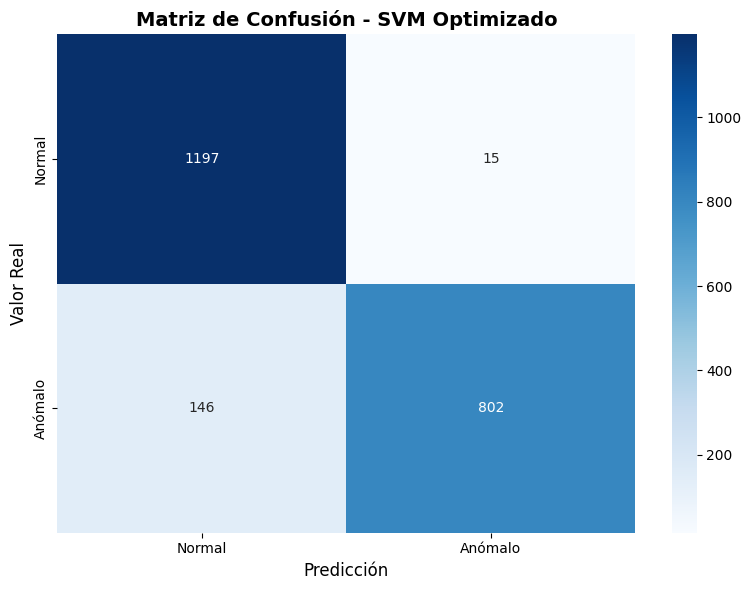


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1197 (Normal predicho correctamente)
  - Falsos Positivos (FP): 15 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 146 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 802 (Anómalo predicho correctamente)


In [ ]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - SVM Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_svm.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

## 6. Modelo 2: XGBoost

### 6.1 Modelo base (sin optimización)

In [ ]:
# Entrenar XGBoost con parámetros por defecto
xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
xgb_base.fit(X_train, y_train)  # XGBoost no requiere escalado

# Predicciones
y_pred_xgb_base = xgb_base.predict(X_test)
y_pred_proba_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

# Métricas
print("RESULTADOS XGBOOST BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_base, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST BASE
Accuracy: 0.9898
Precision: 0.9894
Recall: 0.9873
F1-Score: 0.9884
ROC-AUC: 0.9983

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.2 Optimización con Grid Search

Hiperparámetros importantes de XGBoost:
- n_estimators: Número de árboles
- max_depth: Profundidad máxima de los árboles
- learning_rate: Tasa de aprendizaje
- subsample: Fracción de muestras para cada árbol
- colsample_bytree: Fracción de features para cada árbol

In [ ]:
# Definir la grilla de hiperparámetros
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Grilla de hiperparámetros para XGBoost:")
print(param_grid_xgb)
print(f"\nTotal de combinaciones: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree'])}")

Grilla de hiperparámetros para XGBoost:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7, 9], 'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0]}

Total de combinaciones: 324


In [ ]:
cv_strategy = 5 #Es para usar 5-fold CV, aunque se puede ajustar a 3 para mayor velocidad si es necesario
# Configurar Grid Search para XGBoost
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='f1', 
    n_jobs=-1, 
    verbose=2
)

# Usar la misma muestra que con SVM
X_train_xgb_sample, _, y_train_xgb_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=0.3,  
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Grid Search con muestra
grid_search_xgb.fit(X_train_xgb_sample, y_train_xgb_sample)
print("\nGrid Search completado")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Grid Search completado


In [ ]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS XGBOOST")
print(f"Mejores parámetros: {grid_search_xgb.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_xgb.best_score_:.4f}")

# Modelo final con todos los datos
xgb_best = XGBClassifier(
    n_estimators=grid_search_xgb.best_params_['n_estimators'],
    max_depth=grid_search_xgb.best_params_['max_depth'],
    learning_rate=grid_search_xgb.best_params_['learning_rate'],
    subsample=grid_search_xgb.best_params_['subsample'],
    colsample_bytree=grid_search_xgb.best_params_['colsample_bytree'],
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_best.fit(X_train, y_train)

MEJORES HIPERPARÁMETROS XGBOOST
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Mejor F1-score (validación cruzada): 0.9895


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgb_best = xgb_best.predict(X_test)
y_pred_proba_xgb_best = xgb_best.predict_proba(X_test)[:, 1]

print("RESULTADOS XGBOOST OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_best, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST OPTIMIZADO (TEST SET)
Accuracy: 0.9907
Precision: 0.9895
Recall: 0.9895
F1-Score: 0.9895
ROC-AUC: 0.9990

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.3 Matriz de confusión XGBoost

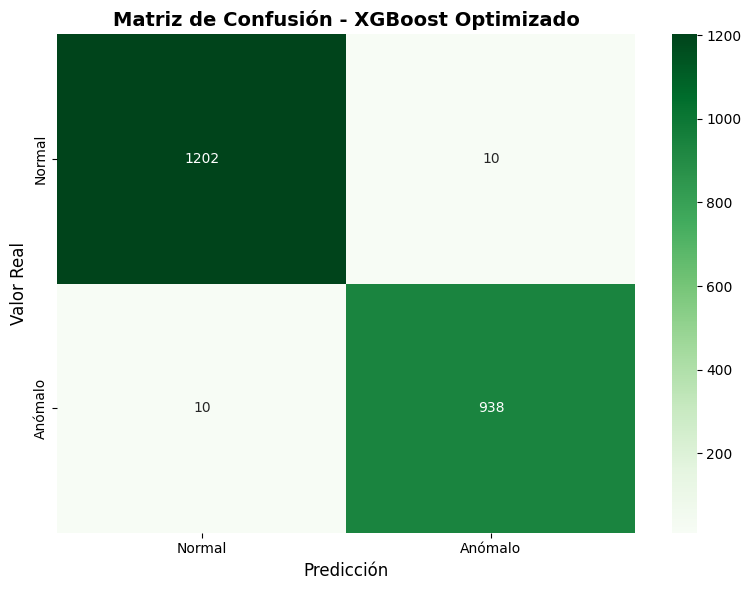


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1202 (Normal predicho correctamente)
  - Falsos Positivos (FP): 10 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 10 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 938 (Anómalo predicho correctamente)


In [ ]:
# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - XGBoost Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

### 6.4 Importancia de features (XGBoost)

In [ ]:
# Obtener importancia de features
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Importancia de features (XGBoost):")
print(feature_importance_xgb)

Importancia de features (XGBoost):
                            feature  importance
8                Usage_Deviation(%)    0.626184
7                Actual_Energy(kwh)    0.258874
9           Cluster_Avg_Energy(kwh)    0.051351
15          Dwelling_Type_Apartment    0.010048
6              Expected_Energy(kwh)    0.008709
0                     Num_Occupants    0.006964
13            Region_Code_IN_KL_ERN    0.006661
3                Connected_Load(kw)    0.006188
5                      Humidity (%)    0.005138
4                     Temperature_C    0.005094
2                   Appliance_Score    0.003867
16  Dwelling_Type_Independent House    0.003674
1                 House_Area (sqft)    0.003341
12            Region_Code_IN_KL_ALP    0.003028
14            Region_Code_IN_KL_TVM    0.000880
11                             Year    0.000000
10                            Month    0.000000
17              Dwelling_Type_Villa    0.000000


---
## 7. Modelo 3: K-Nearest Neighbors (KNN)

### 7.1 Modelo base (sin optimización)

In [ ]:
import time
# KNN base con k=5 y Ball Tree para eficiencia
t0 = time.time() 

knn_base = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='ball_tree',     
    n_jobs=-1
)
knn_base.fit(X_train_scaled, y_train)

print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")

#Predicciones
y_pred_knn_base       = knn_base.predict(X_test_scaled)
y_pred_proba_knn_base = knn_base.predict_proba(X_test_scaled)[:, 1]

print("\nRESULTADOS KNN BASE")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_knn_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn_base, target_names=['Normal', 'Anómalo']))

Tiempo de entrenamiento: 0.03s

RESULTADOS KNN BASE
Accuracy:  0.8583
Precision: 0.9471
Recall:    0.7173
F1-Score:  0.8163
ROC-AUC:   0.8924

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.88      1212
     Anómalo       0.95      0.72      0.82       948

    accuracy                           0.86      2160
   macro avg       0.88      0.84      0.85      2160
weighted avg       0.87      0.86      0.85      2160



### 7.2 Optimización con RandomizedSearchCV

Se usa RandomizedSearchCV en lugar de GridSearchCV porque el espacio de hiperparámetros de KNN es amplio. Se entrena sobre una muestra estratificada del 30 % del conjunto de entrenamiento, igual que se hizo con SVM.

In [ ]:
# Muestra estratificada 30 % para la búsqueda (misma estrategia que SVM)
X_train_knn_sample, _, y_train_knn_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Dataset entrenamiento completo: {len(X_train_scaled):,} muestras")
print(f"Muestra para búsqueda:          {len(X_train_knn_sample):,} muestras (30 %)")

Dataset entrenamiento completo: 8,640 muestras
Muestra para búsqueda:          2,592 muestras (30 %)


In [ ]:
# Espacio de hiperparámetros
param_dist_knn = {
    'n_neighbors': randint(3, 31),                          # k entre 3 y 30
    'weights'    : ['uniform', 'distance'],                 # peso uniforme vs inverso de distancia
    'metric'     : ['euclidean', 'manhattan', 'minkowski'], # métricas de distancia
    'algorithm'  : ['ball_tree', 'kd_tree'],                # algoritmos de índice espacial
    'leaf_size'  : randint(20, 51),                         # tamaño de hoja para el árbol
    'p'          : [1, 2]                                   # Minkowski: 1=Manhattan, 2=Euclidean
}

print("Grilla de hiperparámetros para KNN:")
for k, v in param_dist_knn.items():
    print(f"  {k}: {v}")
print("\nRandomizedSearchCV explorará 30 combinaciones aleatorias")
print("Con 3-fold CV -> 90 entrenamientos sobre la muestra (30 %)")

Grilla de hiperparámetros para KNN:
  n_neighbors: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000136582CD010>
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan', 'minkowski']
  algorithm: ['ball_tree', 'kd_tree']
  leaf_size: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000136587873E0>
  p: [1, 2]

RandomizedSearchCV explorará 30 combinaciones aleatorias
Con 3-fold CV -> 90 entrenamientos sobre la muestra (30 %)


In [ ]:
cv_strategy_knn = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

random_search_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=30,
    cv=cv_strategy_knn,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

t0 = time.time()
random_search_knn.fit(X_train_knn_sample, y_train_knn_sample)
print(f"\n Búsqueda completada en {(time.time()-t0)/60:.1f} min")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Búsqueda completada en 0.0 min


In [ ]:
print("MEJORES HIPERPARÁMETROS KNN")
print("=" * 45)
for param, value in random_search_knn.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\n  Mejor F1 (CV): {random_search_knn.best_score_:.4f}")

MEJORES HIPERPARÁMETROS KNN
  algorithm           : kd_tree
  leaf_size           : 36
  metric              : manhattan
  n_neighbors         : 10
  p                   : 2
  weights             : distance

  Mejor F1 (CV): 0.7982


In [ ]:
# Entrenar modelo final con dataset completo
t0 = time.time()

knn_best = KNeighborsClassifier(
    **random_search_knn.best_params_,
    n_jobs=-1
)
knn_best.fit(X_train_scaled, y_train)

print(f"Modelo entrenado con {len(X_train_scaled):,} muestras en {time.time()-t0:.2f}s")

Modelo entrenado con 8,640 muestras en 0.05s


### 7.3 Evaluación del KNN optimizado

In [ ]:
y_pred_knn_best       = knn_best.predict(X_test_scaled)
y_pred_proba_knn_best = knn_best.predict_proba(X_test_scaled)[:, 1]

print("RESULTADOS KNN OPTIMIZADO (TEST SET)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_knn_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn_best, target_names=['Normal', 'Anómalo']))

RESULTADOS KNN OPTIMIZADO (TEST SET)
Accuracy:  0.8593
Precision: 0.9653
Recall:    0.7046
F1-Score:  0.8146
ROC-AUC:   0.9145

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.81      0.98      0.89      1212
     Anómalo       0.97      0.70      0.81       948

    accuracy                           0.86      2160
   macro avg       0.89      0.84      0.85      2160
weighted avg       0.88      0.86      0.85      2160



### 7.4 Matriz de confusión KNN

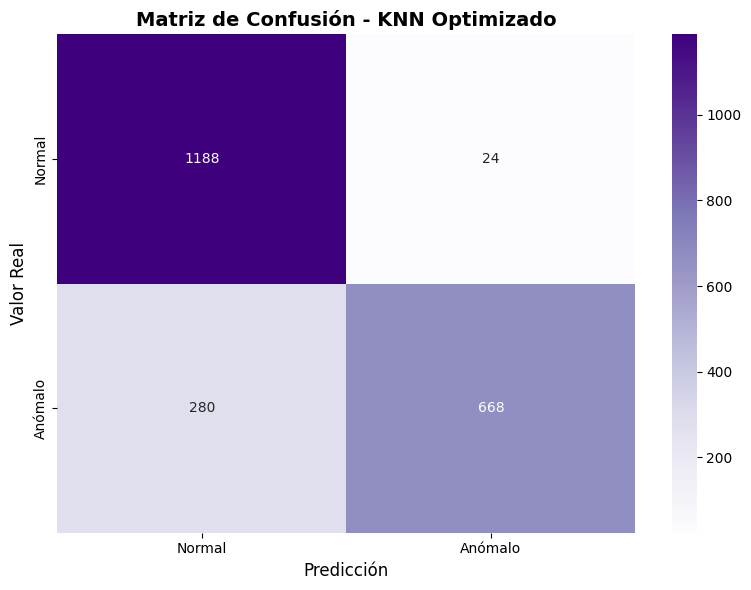


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1188 (Normal predicho correctamente)
  - Falsos Positivos (FP): 24 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 280 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 668 (Anómalo predicho correctamente)


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - KNN Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_knn.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

## 8. Modelo 4: Random Forest (RF)

Se utiliza RandomizedSearchCV con n_iter=30 sobre una muestra estratificada del 30 %, el mismo patrón aplicado con KNN.

### 8.1 Modelo base (sin optimización)

In [ ]:
t0 = time.time()

# Random Forest no requiere datos escalados
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)  # Se usa X_train sin escalar

print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")

# Predicciones
y_pred_rf_base       = rf_base.predict(X_test)
y_pred_proba_rf_base = rf_base.predict_proba(X_test)[:, 1]

# Métricas
print("\nRESULTADOS RANDOM FOREST BASE")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_base, target_names=['Normal', 'Anómalo']))

Tiempo de entrenamiento: 0.92s

RESULTADOS RANDOM FOREST BASE
Accuracy:  0.9880
Precision: 0.9883
Recall:    0.9842
F1-Score:  0.9863
ROC-AUC:   0.9994

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.98      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 8.2 Optimización con RandomizedSearchCV

Hiperparámetros a explorar:
- n_estimators: Número de árboles (más árboles = más estable, pero más lento)
- max_depth: Profundidad máxima (controla overfitting)
- min_samples_split: Mínimo de muestras para dividir un nodo
- min_samples_leaf: Mínimo de muestras en hoja (suaviza el modelo)
- max_features: Features consideradas por árbol ('sqrt' = √p, 'log2' = log₂p)

In [ ]:
# Muestra estratificada 30 % que es la misma estrategia que SVM y KNN
X_train_rf_sample, _, y_train_rf_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Dataset entrenamiento completo: {len(X_train):,} muestras")
print(f"Muestra para búsqueda:          {len(X_train_rf_sample):,} muestras (30 %)")

Dataset entrenamiento completo: 8,640 muestras
Muestra para búsqueda:          2,592 muestras (30 %)


In [ ]:
# Espacio de hiperparámetros
param_dist_rf = {
    'n_estimators'    : randint(100, 501),      # Entre 100 y 500 árboles
    'max_depth'       : randint(10, 31),         # Profundidad entre 10 y 30
    'min_samples_split': randint(2, 21),         # Entre 2 y 20
    'min_samples_leaf' : randint(1, 11),         # Entre 1 y 10
    'max_features'    : ['sqrt', 'log2', 0.3, 0.5]  # Subconjunto de features
}

print("Espacio de hiperparámetros para Random Forest:")
for k, v in param_dist_rf.items():
    print(f"  {k}: {v}")
print("\nRandomizedSearchCV explorará 30 combinaciones aleatorias")

Espacio de hiperparámetros para Random Forest:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000013658271DF0>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000013658257AD0>
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000136582555E0>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000136582571A0>
  max_features: ['sqrt', 'log2', 0.3, 0.5]

RandomizedSearchCV explorará 30 combinaciones aleatorias


In [ ]:
cv_strategy_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',  # Manejo automático del desbalance de clases
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=30,               # 30 combinaciones aleatorias
    cv=cv_strategy_rf,       # 5-fold estratificado
    scoring='roc_auc',       # Optimizar ROC-AUC
    refit=True,              # Reentrenar con los mejores parámetros al finalizar
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

t0 = time.time()
random_search_rf.fit(X_train_rf_sample, y_train_rf_sample)
print(f"\nBúsqueda completada en {(time.time()-t0)/60:.1f} min")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Búsqueda completada en 1.8 min


In [ ]:
print("MEJORES HIPERPARÁMETROS RANDOM FOREST")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param:25s}: {value}")
print(f"\n  Mejor ROC-AUC (CV): {random_search_rf.best_score_:.4f}")

MEJORES HIPERPARÁMETROS RANDOM FOREST
  max_depth                : 17
  max_features             : 0.5
  min_samples_leaf         : 2
  min_samples_split        : 7
  n_estimators             : 153

  Mejor ROC-AUC (CV): 0.9992


In [ ]:
# Entrenar modelo final con TODOS los datos de entrenamiento
t0 = time.time()

rf_best = RandomForestClassifier(
    **random_search_rf.best_params_, #Es para usar los mejores hiperparámetros encontrados
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)  # Datos sin escalar — RF no lo necesita

print(f"Modelo entrenado con {len(X_train):,} muestras en {time.time()-t0:.2f}s")

Modelo entrenado con 8,640 muestras en 1.81s


### 8.3 Evaluación del Random Forest optimizado

In [ ]:
y_pred_rf_best       = rf_best.predict(X_test)
y_pred_proba_rf_best = rf_best.predict_proba(X_test)[:, 1]

print("RESULTADOS RANDOM FOREST OPTIMIZADO (TEST SET)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_best, target_names=['Normal', 'Anómalo']))

RESULTADOS RANDOM FOREST OPTIMIZADO (TEST SET)
Accuracy:  0.9935
Precision: 0.9916
Recall:    0.9937
F1-Score:  0.9926
ROC-AUC:   0.9994

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 8.4 Matriz de confusión Random Forest

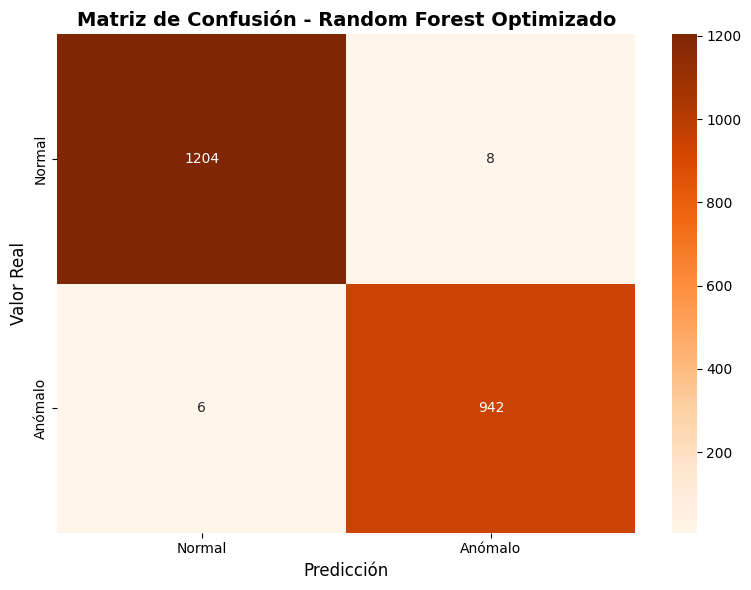


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1204 (Normal predicho correctamente)
  - Falsos Positivos (FP): 8 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 6 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 942 (Anómalo predicho correctamente)


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

### 8.5 Importancia de features (Random Forest)

In [ ]:
feature_importance_rf = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Agregar importancia acumulada
feature_importance_rf['importance_pct'] = feature_importance_rf['importance'] * 100
feature_importance_rf['cumulative_pct'] = feature_importance_rf['importance_pct'].cumsum()

print("Importancia de features — Random Forest Optimizado:")
print(feature_importance_rf.round(4).to_string(index=False))

Importancia de features — Random Forest Optimizado:
                        feature  importance  importance_pct  cumulative_pct
             Usage_Deviation(%)      0.4367         43.6721         43.6721
             Actual_Energy(kwh)      0.4334         43.3371         87.0092
           Expected_Energy(kwh)      0.0821          8.2106         95.2198
        Cluster_Avg_Energy(kwh)      0.0206          2.0633         97.2831
                  Num_Occupants      0.0056          0.5594         97.8425
                Appliance_Score      0.0045          0.4455         98.2881
             Connected_Load(kw)      0.0042          0.4183         98.7064
                  Temperature_C      0.0035          0.3457         99.0520
              House_Area (sqft)      0.0019          0.1904         99.2424
          Region_Code_IN_KL_TVM      0.0017          0.1703         99.4127
                   Humidity (%)      0.0015          0.1514         99.5641
          Region_Code_IN_KL_ERN     

In [ ]:
# Guardar modelo RF
with open('modelo_rf_optimizado.pkl', 'wb') as f:
    pickle.dump(rf_best, f)
print("Modelo Random Forest guardado: modelo_rf_optimizado.pkl")

Modelo Random Forest guardado: modelo_rf_optimizado.pkl


## 9. Comparación de modelos: SVM vs XGBoost vs KNN vs Random Forest

In [ ]:
# Tabla comparativa completa — 8 modelos (base + optimizado de cada algoritmo)
comparison_full_df = pd.DataFrame({
    'Modelo': [
        'SVM Base', 'SVM Optimizado',
        'XGBoost Base', 'XGBoost Optimizado',
        'KNN Base', 'KNN Optimizado',
        'RF Base', 'RF Optimizado'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm_base),  accuracy_score(y_test, y_pred_svm_best),
        accuracy_score(y_test, y_pred_xgb_base),  accuracy_score(y_test, y_pred_xgb_best),
        accuracy_score(y_test, y_pred_knn_base),  accuracy_score(y_test, y_pred_knn_best),
        accuracy_score(y_test, y_pred_rf_base),   accuracy_score(y_test, y_pred_rf_best),
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm_base),  precision_score(y_test, y_pred_svm_best),
        precision_score(y_test, y_pred_xgb_base),  precision_score(y_test, y_pred_xgb_best),
        precision_score(y_test, y_pred_knn_base),  precision_score(y_test, y_pred_knn_best),
        precision_score(y_test, y_pred_rf_base),   precision_score(y_test, y_pred_rf_best),
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm_base),  recall_score(y_test, y_pred_svm_best),
        recall_score(y_test, y_pred_xgb_base),  recall_score(y_test, y_pred_xgb_best),
        recall_score(y_test, y_pred_knn_base),  recall_score(y_test, y_pred_knn_best),
        recall_score(y_test, y_pred_rf_base),   recall_score(y_test, y_pred_rf_best),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm_base),  f1_score(y_test, y_pred_svm_best),
        f1_score(y_test, y_pred_xgb_base),  f1_score(y_test, y_pred_xgb_best),
        f1_score(y_test, y_pred_knn_base),  f1_score(y_test, y_pred_knn_best),
        f1_score(y_test, y_pred_rf_base),   f1_score(y_test, y_pred_rf_best),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_svm_base),  roc_auc_score(y_test, y_pred_proba_svm_best),
        roc_auc_score(y_test, y_pred_xgb_base),        roc_auc_score(y_test, y_pred_proba_xgb_best),
        roc_auc_score(y_test, y_pred_proba_knn_base),  roc_auc_score(y_test, y_pred_proba_knn_best),
        roc_auc_score(y_test, y_pred_proba_rf_base),   roc_auc_score(y_test, y_pred_proba_rf_best),
    ],
})

print("COMPARACIÓN COMPLETA: SVM vs XGBoost vs KNN vs Random Forest\n")
print(comparison_full_df.round(4).to_string(index=False))

best_idx = comparison_full_df['F1-Score'].idxmax()
print(f"\nMejor modelo general: {comparison_full_df.loc[best_idx, 'Modelo']}")
print(f"   F1-Score: {comparison_full_df.loc[best_idx, 'F1-Score']:.4f}")

COMPARACIÓN COMPLETA: SVM vs XGBoost vs KNN vs Random Forest

            Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
          SVM Base    0.8931     0.9786  0.7732    0.8639   0.9420
    SVM Optimizado    0.9255     0.9816  0.8460    0.9088   0.9670
      XGBoost Base    0.9898     0.9894  0.9873    0.9884   0.9895
XGBoost Optimizado    0.9907     0.9895  0.9895    0.9895   0.9990
          KNN Base    0.8583     0.9471  0.7173    0.8163   0.8924
    KNN Optimizado    0.8593     0.9653  0.7046    0.8146   0.9145
           RF Base    0.9880     0.9883  0.9842    0.9863   0.9994
     RF Optimizado    0.9935     0.9916  0.9937    0.9926   0.9994

Mejor modelo general: RF Optimizado
   F1-Score: 0.9926


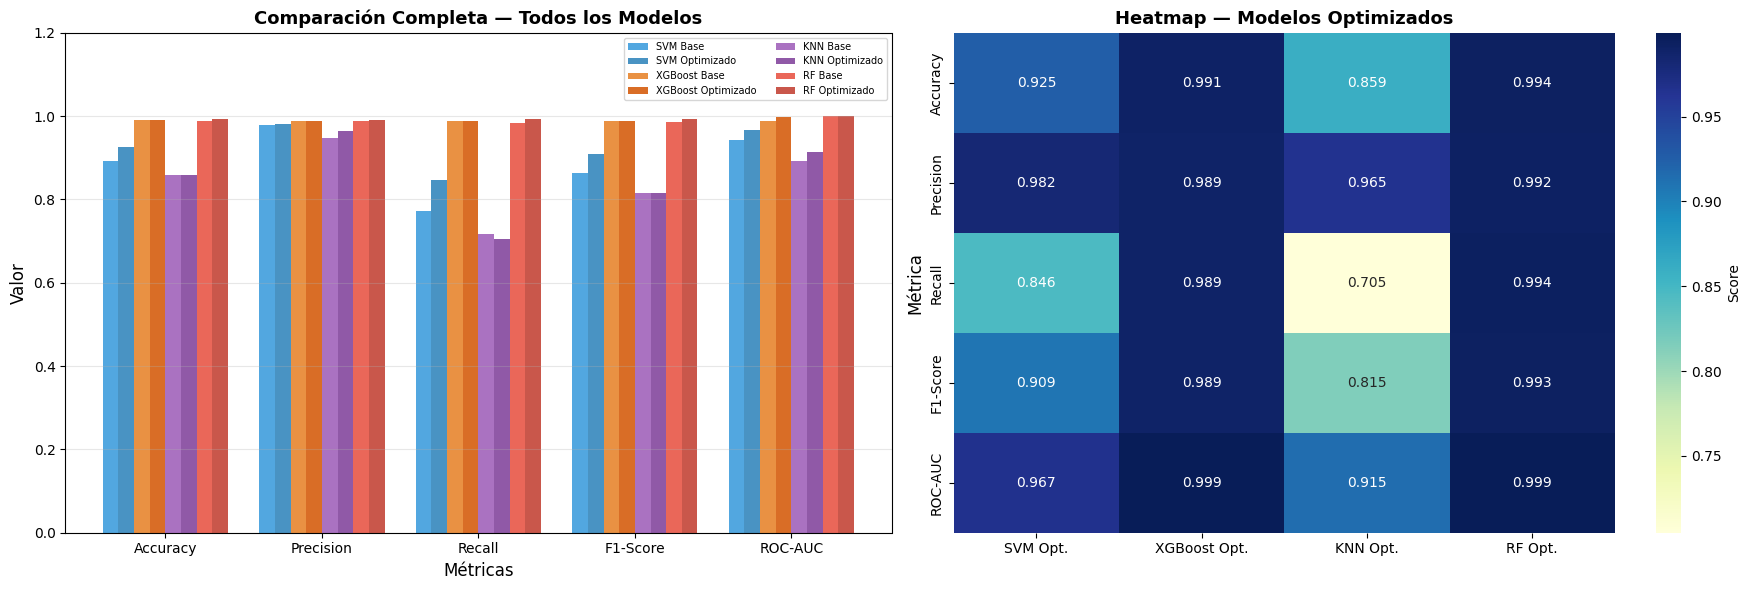

In [ ]:
# Visualización comparativa
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Solo modelos optimizados para el heatmap
opt_only = comparison_full_df[comparison_full_df['Modelo'].isin(
    ['SVM Optimizado', 'XGBoost Optimizado', 'KNN Optimizado', 'RF Optimizado']
)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras — todos los modelos
x = np.arange(len(metrics))
width = 0.10
colors = ['#3498db', '#2980b9', '#e67e22', '#d35400', '#9b59b6', '#7d3c98', '#e74c3c', '#c0392b']

for i, (_, row) in enumerate(comparison_full_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics].values, width,
                label=row['Modelo'], alpha=0.85, color=colors[i])

axes[0].set_xlabel('Métricas', fontsize=12)
axes[0].set_ylabel('Valor', fontsize=12)
axes[0].set_title('Comparación Completa — Todos los Modelos', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width * 3.5)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.2])

# Heatmap — solo optimizados
sns.heatmap(opt_only[metrics].T.astype(float), annot=True, fmt='.3f',
            cmap='YlGnBu', cbar_kws={'label': 'Score'}, ax=axes[1],
            xticklabels=['SVM Opt.', 'XGBoost Opt.', 'KNN Opt.', 'RF Opt.'])
axes[1].set_title('Heatmap — Modelos Optimizados', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Métrica', fontsize=12)

plt.tight_layout()
plt.show()

### 9.1 Curvas ROC — SVM vs XGBoost vs KNN vs Random Forest

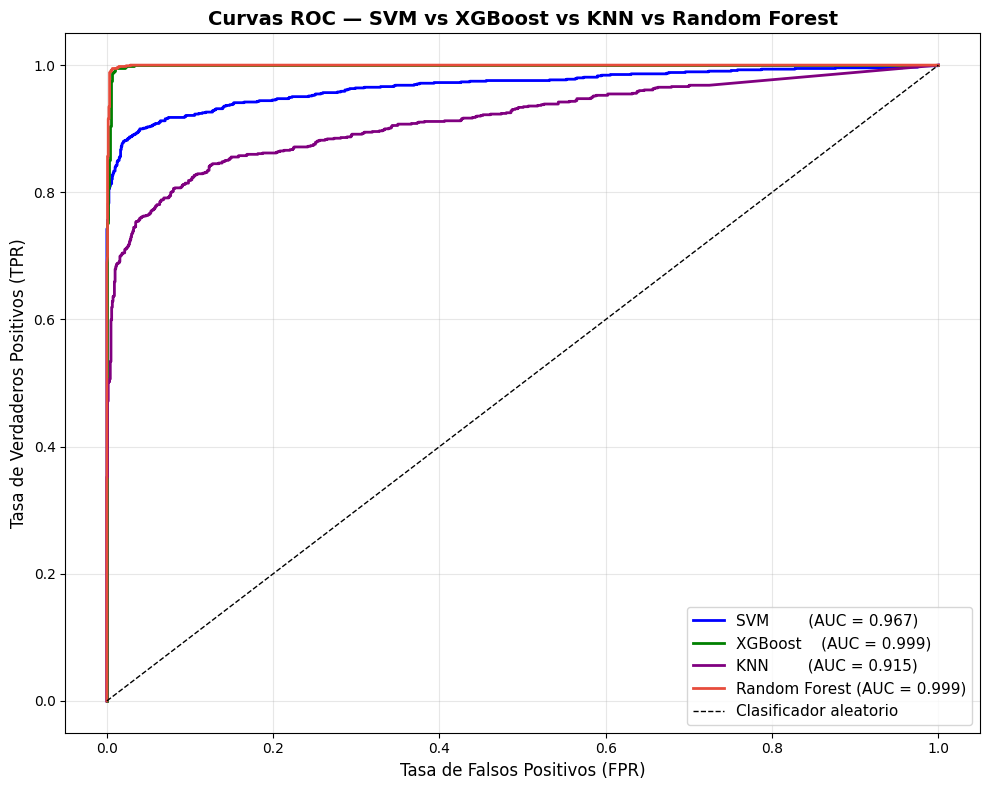

In [ ]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm_best)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_best)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn_best)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_pred_proba_rf_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm,
         label=f'SVM        (AUC = {roc_auc_score(y_test, y_pred_proba_svm_best):.3f})',
         linewidth=2, color='blue')
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost    (AUC = {roc_auc_score(y_test, y_pred_proba_xgb_best):.3f})',
         linewidth=2, color='green')
plt.plot(fpr_knn, tpr_knn,
         label=f'KNN        (AUC = {roc_auc_score(y_test, y_pred_proba_knn_best):.3f})',
         linewidth=2, color='purple')
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf_best):.3f})',
         linewidth=2, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — SVM vs XGBoost vs KNN vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Guardar todos los modelos

In [ ]:
# Guardar todos los modelos entrenados
with open('modelo_svm_optimizado.pkl', 'wb') as f:
    pickle.dump(svm_best, f)
print("Modelo SVM guardado: modelo_svm_optimizado.pkl")

with open('modelo_xgboost_optimizado.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)
print("Modelo XGBoost guardado: modelo_xgboost_optimizado.pkl")

with open('modelo_knn_optimizado.pkl', 'wb') as f:
    pickle.dump(knn_best, f)
print("Modelo KNN guardado: modelo_knn_optimizado.pkl")

with open('modelo_rf_optimizado.pkl', 'wb') as f:
    pickle.dump(rf_best, f)
print("Modelo Random Forest guardado: modelo_rf_optimizado.pkl")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler guardado: scaler.pkl")

Modelo SVM guardado: modelo_svm_optimizado.pkl
Modelo XGBoost guardado: modelo_xgboost_optimizado.pkl
Modelo KNN guardado: modelo_knn_optimizado.pkl
Modelo Random Forest guardado: modelo_rf_optimizado.pkl
Scaler guardado: scaler.pkl


## 11. Datos obtenidos

In [ ]:
print(f"\n1. DATOS:")
print(f"   - Total de muestras: {len(df):,}")
print(f"   - Features utilizadas: {len(X.columns)}")
print(f"   - Train/Test split: {len(X_train)}/{len(X_test)}")

print(f"\n2. MODELOS ENTRENADOS:")
print(f"   - SVM con Grid Search (muestra 30 %)")
print(f"   - XGBoost con Grid Search (muestra 30 %)")
print(f"   - KNN con RandomizedSearch (muestra 30 %)")
print(f"   - Random Forest con RandomizedSearch (muestra 30 %)")

print(f"\n3. MEJOR MODELO (por F1-Score):")
best_idx = comparison_full_df['F1-Score'].idxmax()
best = comparison_full_df.loc[best_idx]
for col in ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    val = best[col]
    if isinstance(val, float):
        print(f"   - {col}: {val:.4f}")
    else:
        print(f"   - {col}: {val}")


1. DATOS:
   - Total de muestras: 10,800
   - Features utilizadas: 18
   - Train/Test split: 8640/2160

2. MODELOS ENTRENADOS:
   - SVM con Grid Search (muestra 30 %)
   - XGBoost con Grid Search (muestra 30 %)
   - KNN con RandomizedSearch (muestra 30 %)
   - Random Forest con RandomizedSearch (muestra 30 %)

3. MEJOR MODELO (por F1-Score):
   - Modelo: RF Optimizado
   - Accuracy: 0.9935
   - Precision: 0.9916
   - Recall: 0.9937
   - F1-Score: 0.9926
   - ROC-AUC: 0.9994
